In [1]:
import numpy as np
import time
import sys


if '../src' in sys.path:
    sys.path.remove('../src') 

sys.path.append('../src')

from blackjack_core import hand_berechnen, deck_erstellen, karte_austeilen
from blackjack_t2 import berechne_kommende_karte, gewinnt_spieler, denk_logik, spielerrunde

# Testen der "21er Schätzer" 

In [17]:
a_21er_test_1 = []
a_21er_test_2 = []
a1 = [7] #9,8,6,5,4,3,2,1
wert1 = []
ueberschiesst1 = []
alle_wert1 = []
gewinnt_spieler1 = []


a2 = [8, 7, 6, 5, 4, 3, 2, 1]
wert2 = []
ueberschiesst2 = []
alle_wert1 = []

wert_nach_schaetzung = 0
gewinnt_spieler2 = []

In [20]:
deck = deck_erstellen(6)
bisherige_karten = []
ueberschiesst = 0
uebrige_karten = len(deck)


for i in a1:
    ueberschiesst = 0
    # teil_alle_wert1 = []
    for j in range(100000):
        if uebrige_karten <= 5:
            deck = deck_erstellen(6)
            spieler_buget = 1000
            dealer_buget = 1000
            bisherige_karten = []
            uebrige_karten = 0
            uebrige_karten = len(deck)
        
        spieler_buget, dealer_buget, spieler_karten_total, dealer_karten_total, deck, bisherige_karten, spielerstrategie, dealerstrategie, gewinnt_spieler = spielerrunde(1000, 1000, deck, bisherige_karten, 'erster Test', 'erster Test', a=i)
        gewinnt_spieler1.append(gewinnt_spieler)
        t_hand = hand_berechnen(spieler_karten_total)
        wert_nach_schaetzung += t_hand

        # teil_alle_wert1.append(t_hand)

        # print(teil_alle_wert1)

        if hand_berechnen(spieler_karten_total) > 21:
            ueberschiesst += 1

        
        uebrige_karten = len(deck)
        
    # alle_wert1.append(teil_alle_wert1)
    wert_nach_schaetzung /= 100000
    ueberschiesst = ueberschiesst / 100000
    wert1.append(wert_nach_schaetzung)
    ueberschiesst1.append(ueberschiesst)
    print('wert ',wert_nach_schaetzung)
    print('ueberschiesst ', ueberschiesst)

wert  18.9320694056
ueberschiesst  0.21032


In [21]:
total_gewinnt = 0
total_verlust = 0
for i in gewinnt_spieler1:
    if i == True:
        total_gewinnt += 1
    else:
        total_verlust += 1

print(total_gewinnt)
print(total_verlust)


115899
84101


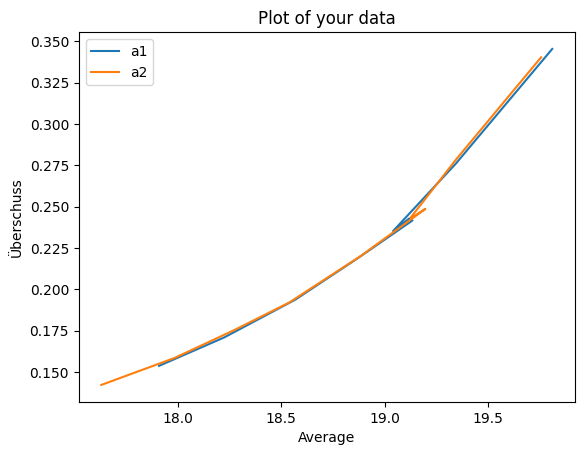

In [69]:
import matplotlib.pyplot as plt

plt.plot(wert1, ueberschiesst1, label='a1')
plt.legend()
plt.title('Plot of your data')


plt.plot(wert2, ueberschiesst2, label='a2')
plt.xlabel('Average')
plt.ylabel('Überschuss')
plt.legend()
plt.title('Plot of your data')
plt.show()
